# Advanced Data Visualization and Storytelling with Python

## 1. Introduction

Data visualization is an important part of understanding complex datasets because well-designed visualizations can reveal patterns, trends, relationships, and unusual observations more clearly than raw tables alone. This project focuses on transforming the Superstore sales dataset into a coherent visual narrative that can be understood by both technical and non-technical audiences.

The analysis examines business performance across time, product categories, and geographical regions. Rather than presenting isolated charts, the visualizations are organized around a sequence of questions: how business performance changes over time, which categories contribute to sales and profit, how performance differs between regions, how sales relate to profit at the transaction level, and which category-region combinations show notable profitability patterns.

Python libraries including Pandas, NumPy, Matplotlib, Seaborn, and Plotly were used for data preparation, analysis, and visualization. The final visual narrative uses multiple chart types to communicate different aspects of the dataset and identify potential business implications.

## 2. Objective

The main objectives of this project are:

- Analyze the Superstore dataset to understand overall business performance.
- Examine sales and profit trends over time.
- Compare sales, profit, and profit margins across product categories.
- Analyze regional differences in sales and profitability.
- Explore the relationship between transaction-level sales and profit.
- Examine the distribution and variation of profit across categories.
- Identify notable category-region profitability patterns.
- Present the findings as a coherent visual story suitable for a non-technical audience.

## 3. Dataset Description

The dataset used for this project is the Superstore sales dataset, which contains transaction-level information about customer orders, products, sales, quantities, discounts, and profits.

The original CSV contained 10,800 rows and 21 columns. During the initial inspection, the dataset was found to contain a main transaction table followed by an appended section containing returns-related information. For the business-performance analysis, the main transaction records were isolated, resulting in 9,994 transaction rows.

The main variables used in this project include:

- Order Date and Ship Date
- Ship Mode
- Customer and Segment information
- Region, State, and City
- Product Category and Sub-Category
- Sales
- Quantity
- Discount
- Profit

The transaction data covers orders from January 2015 through December 2018. This time range provides sufficient observations for examining monthly business trends.

## 4. Tools and Technologies

The following Python tools and libraries were used:

- **Python** — primary programming language.
- **Pandas** — data loading, cleaning, transformation, aggregation, and analysis.
- **NumPy** — numerical operations and calculations.
- **Matplotlib** — creation and customization of visualizations.
- **Seaborn** — statistical and categorical visualizations, including scatter plots, box plots, and heatmaps.
- **Plotly** — installed as part of the visualization environment for interactive visualization capabilities.
- **Jupyter Notebook** — development environment used to organize the analysis, code, visualizations, and explanations.

## 5. Data Preparation

The dataset was first loaded using Pandas and inspected for its dimensions, data types, missing values, and duplicate records.

The original file contained 10,800 rows. Inspection showed that the first 9,994 rows represented the main transaction dataset, while the remaining 806 rows contained appended returns-related information rather than normal transaction records. Therefore, the analysis was performed using the 9,994 transaction rows.

The following preparation steps were performed:

1. The main transaction records were isolated into a separate DataFrame named `df_clean`.
2. Duplicate transaction rows were checked. No duplicate rows were present within the cleaned transaction dataset.
3. `Order Date` and `Ship Date` were converted from text to datetime format.
4. The cleaned transaction data contained 11 missing values, all in the `Postal Code` column.
5. The missing postal-code values were retained rather than imputed because postal code was not required for the planned business visualizations.
6. Additional time-based columns were created from `Order Date`, including Year, Month, Month Name, and Year-Month.
7. Aggregated datasets were created for category and regional performance analysis.

The final analysis therefore focused on the 9,994 main transaction records while preserving the original transaction-level sales, quantity, discount, and profit information required for the visual analysis.

## 6. import library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
df = pd.read_csv("../data/superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 10800
Columns: 21
<class 'pandas.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  str    
 1   Order ID       10800 non-null  str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float6

In [6]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,10800,10800,9994,9994,9994,9994,9994,9994,9994,9994,...,9983.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,10001,5015,1236,1334,4,793,793,3,1,531,...,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,Yes,CA-2018-100111,9/5/2017,12/16/2016,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,800,28,38,35,5968,37,37,5191,9994,915,...,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55245.233297,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32038.715955,NaN,NaN,NaN,NaN,NaN,623.245101,2.225110,0.206452,234.260108
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,57103.000000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000


In [7]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [8]:
df.isnull().sum()

Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64

In [10]:
missing = df.isnull().sum()

print("Columns with missing values:")
print(missing[missing > 0])

print("\nTotal missing values:", missing.sum())

Columns with missing values:
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64

Total missing values: 15325


In [11]:
# Check rows where Order Date is missing
blank_rows = df[df["Order Date"].isna()]

print("Rows with missing Order Date:", len(blank_rows))

print("\nFirst 5 blank rows:")
display(blank_rows.head())

print("\nNon-null values in these rows:")
print(blank_rows.notna().sum().sort_values(ascending=False))

Rows with missing Order Date: 806

First 5 blank rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9994,Person,Region,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9995,Anna Andreadi,West,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9996,Chuck Magee,East,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9997,Kelly Williams,Central,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9998,Cassandra Brandow,South,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Non-null values in these rows:
Row ID           806
Order ID         806
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country            0
City               0
State              0
Postal Code        0
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64


In [12]:
# Count rows that are completely empty
completely_blank = df.isna().all(axis=1).sum()

print("Completely blank rows:", completely_blank)

Completely blank rows: 0


In [13]:
df_nonblank = df.dropna(how="all")

print("Rows before removing completely blank rows:", len(df))
print("Rows after removing completely blank rows:", len(df_nonblank))
print("Duplicate rows among non-blank data:", df_nonblank.duplicated().sum())

Rows before removing completely blank rows: 10800
Rows after removing completely blank rows: 10800
Duplicate rows among non-blank data: 504


In [14]:
# Inspect the transition around the suspicious rows

print(df.iloc[9985:10010][["Row ID", "Order ID", "Order Date", "Category", "Sales", "Profit"]].to_string(index=True))

                  Row ID        Order ID  Order Date         Category    Sales   Profit
9985                9986  CA-2016-100251   5/17/2016  Office Supplies   55.600  16.1240
9986                9987  CA-2017-125794   9/29/2017       Technology   36.240  15.2208
9987                9988  CA-2018-163629  11/17/2018       Technology   79.990  28.7964
9988                9989  CA-2018-163629  11/17/2018       Technology  206.100  55.6470
9989                9990  CA-2015-110422   1/21/2015        Furniture   25.248   4.1028
9990                9991  CA-2018-121258   2/26/2018        Furniture   91.960  15.6332
9991                9992  CA-2018-121258   2/26/2018       Technology  258.576  19.3932
9992                9993  CA-2018-121258   2/26/2018  Office Supplies   29.600  13.3200
9993                9994  CA-2018-119914    5/4/2018  Office Supplies  243.160  72.9480
9994              Person          Region         NaN              NaN      NaN      NaN
9995       Anna Andreadi        

In [15]:
print("Rows where Order Date is missing:", df["Order Date"].isna().sum())

print("\nUnique Row ID values among missing-date rows:")
print(df.loc[df["Order Date"].isna(), "Row ID"].head(20).tolist())

Rows where Order Date is missing: 806

Unique Row ID values among missing-date rows:
['Person', 'Anna Andreadi', 'Chuck Magee', 'Kelly Williams', 'Cassandra Brandow', 'Returned', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes']


In [16]:
print(df.iloc[9994:].head(20).to_string(index=True))

                  Row ID        Order ID Order Date Ship Date Ship Mode Customer ID Customer Name Segment Country City State  Postal Code Region Product ID Category Sub-Category Product Name  Sales  Quantity  Discount  Profit
9994              Person          Region        NaN       NaN       NaN         NaN           NaN     NaN     NaN  NaN   NaN          NaN    NaN        NaN      NaN          NaN          NaN    NaN       NaN       NaN     NaN
9995       Anna Andreadi            West        NaN       NaN       NaN         NaN           NaN     NaN     NaN  NaN   NaN          NaN    NaN        NaN      NaN          NaN          NaN    NaN       NaN       NaN     NaN
9996         Chuck Magee            East        NaN       NaN       NaN         NaN           NaN     NaN     NaN  NaN   NaN          NaN    NaN        NaN      NaN          NaN          NaN    NaN       NaN       NaN     NaN
9997      Kelly Williams         Central        NaN       NaN       NaN         NaN           Na

In [17]:
print(df.iloc[9994:].shape)

(806, 21)


In [18]:
print(df.iloc[9994:][["Row ID", "Order ID"]].tail(20).to_string(index=True))

      Row ID        Order ID
10780    Yes  US-2018-118087
10781    Yes  US-2018-118087
10782    Yes  US-2018-118087
10783    Yes  US-2018-118087
10784    Yes  US-2018-118087
10785    Yes  US-2018-118087
10786    Yes  US-2018-123834
10787    Yes  US-2018-136679
10788    Yes  US-2018-136679
10789    Yes  US-2018-147886
10790    Yes  US-2018-147886
10791    Yes  US-2018-147886
10792    Yes  US-2018-147886
10793    Yes  US-2018-147886
10794    Yes  US-2018-147886
10795    Yes  US-2018-147886
10796    Yes  US-2018-147998
10797    Yes  US-2018-151127
10798    Yes  US-2018-155999
10799    Yes  US-2018-155999


In [19]:
# Keep only the main transaction dataset
df_clean = df.iloc[:9994].copy()

print("Original dataset shape:", df.shape)
print("Analysis dataset shape:", df_clean.shape)

Original dataset shape: (10800, 21)
Analysis dataset shape: (9994, 21)


In [20]:
print("Missing values in main transaction data:")
print(df_clean.isnull().sum())

print("\nTotal missing values:", df_clean.isnull().sum().sum())

Missing values in main transaction data:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

Total missing values: 11


In [21]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [22]:
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"])

print(df_clean[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [23]:
missing_postal = df_clean[df_clean["Postal Code"].isna()]

print("Rows with missing Postal Code:", len(missing_postal))

display(
    missing_postal[
        ["Order ID", "Customer Name", "City", "State", "Postal Code", "Region"]
    ]
)

Rows with missing Postal Code: 11


,Order ID,Customer Name,City,State,Postal Code,Region
2234,CA-2018-104066,Quincy Jones,Burlington,Vermont,NaN,East
5274,CA-2016-162887,Stewart Visinsky,Burlington,Vermont,NaN,East
8798,US-2017-150140,Valerie Mitchum,Burlington,Vermont,NaN,East
9146,US-2017-165505,Claudia Bergmann,Burlington,Vermont,NaN,East
9147,US-2017-165505,Claudia Bergmann,Burlington,Vermont,NaN,East
9148,US-2017-165505,Claudia Bergmann,Burlington,Vermont,NaN,East
9386,US-2018-127292,Raymond Messe,Burlington,Vermont,NaN,East
9387,US-2018-127292,Raymond Messe,Burlington,Vermont,NaN,East
9388,US-2018-127292,Raymond Messe,Burlington,Vermont,NaN,East
9389,US-2018-127292,Raymond Messe,Burlington,Vermont,NaN,East


In [24]:
print(
    missing_postal[
        ["City", "State", "Region"]
    ].value_counts()
)

City        State    Region
Burlington  Vermont  East      11
Name: count, dtype: int64


In [25]:
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"])

print(df_clean[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [26]:
print("Order date range:")
print(df_clean["Order Date"].min(), "to", df_clean["Order Date"].max())

print("\nShip date range:")
print(df_clean["Ship Date"].min(), "to", df_clean["Ship Date"].max())

Order date range:
2015-01-03 00:00:00 to 2018-12-30 00:00:00

Ship date range:
2015-01-07 00:00:00 to 2019-01-05 00:00:00


In [30]:
df_clean["Year"] = df_clean["Order Date"].dt.year
df_clean["Month"] = df_clean["Order Date"].dt.month
df_clean["Month Name"] = df_clean["Order Date"].dt.strftime("%b")

In [31]:
df_clean["Year-Month"] = df_clean["Order Date"].dt.to_period("M").astype(str)

In [32]:
df_clean[["Order Date", "Year", "Month", "Month Name", "Year-Month"]].head()

,Order Date,Year,Month,Month Name,Year-Month
0,2017-11-08,2017,11,Nov,2017-11
1,2017-11-08,2017,11,Nov,2017-11
2,2017-06-12,2017,6,Jun,2017-06
3,2016-10-11,2016,10,Oct,2016-10
4,2016-10-11,2016,10,Oct,2016-10


## 6. Exploratory Analysis

After data preparation, the cleaned dataset contained 9,994 transaction records covering the period from January 2015 to December 2018.

The overall dataset contained:

- **Total Sales:** $2,297,200.86
- **Total Profit:** $286,397.02
- **Total Quantity:** 37,873
- **Unique Orders:** 5,009

The analysis was then divided into several perspectives: time-based performance, category performance, regional performance, transaction-level sales and profit relationships, profit distributions, and category-region profitability.

These perspectives were selected to create a progressive visual narrative. The analysis begins with the overall business trend and then moves toward increasingly detailed comparisons and relationships.

In [33]:
total_sales = df_clean["Sales"].sum()
total_profit = df_clean["Profit"].sum()
total_quantity = df_clean["Quantity"].sum()
total_orders = df_clean["Order ID"].nunique()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Quantity: {total_quantity:,.0f}")
print(f"Unique Orders: {total_orders:,}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Quantity: 37,873
Unique Orders: 5,009


In [34]:
print("Categories:")
print(df_clean["Category"].value_counts())

print("\nRegions:")
print(df_clean["Region"].value_counts())

print("\nSegments:")
print(df_clean["Segment"].value_counts())

Categories:
Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

Regions:
Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

Segments:
Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64


In [35]:
category_performance = (
    df_clean.groupby("Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Order ID", "nunique")
    )
    .sort_values("Sales", ascending=False)
)

category_performance

,Sales,Profit,Quantity,Orders
Category,,,,
Technology,836154.0330,145454.9481,6939.0,1544
Furniture,741999.7953,18451.2728,8028.0,1764
Office Supplies,719047.0320,122490.8008,22906.0,3742


In [36]:
category_performance["Profit Margin %"] = (
    category_performance["Profit"] /
    category_performance["Sales"] * 100
).round(2)

category_performance

,Sales,Profit,Quantity,Orders,Profit Margin %
Category,,,,,
Technology,836154.0330,145454.9481,6939.0,1544,17.40
Furniture,741999.7953,18451.2728,8028.0,1764,2.49
Office Supplies,719047.0320,122490.8008,22906.0,3742,17.04


In [37]:
region_performance = (
    df_clean.groupby("Region")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Order ID", "nunique")
    )
    .sort_values("Sales", ascending=False)
)

region_performance["Profit Margin %"] = (
    region_performance["Profit"] /
    region_performance["Sales"] * 100
).round(2)

region_performance

,Sales,Profit,Quantity,Orders,Profit Margin %
Region,,,,,
West,725457.8245,108418.4489,12266.0,1611,14.94
East,678781.2400,91522.7800,10618.0,1401,13.48
Central,501239.8908,39706.3625,8780.0,1175,7.92
South,391721.9050,46749.4303,6209.0,822,11.93


In [38]:
monthly_performance = (
    df_clean.groupby("Year-Month")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

monthly_performance.head()

,Year-Month,Sales,Profit
0,2015-01,14236.895,2450.1907
1,2015-02,4519.892,862.3084
2,2015-03,55691.009,498.7299
3,2015-04,28295.345,3488.8352
4,2015-05,23648.287,2738.7096


In [39]:
monthly_performance.tail()

,Year-Month,Sales,Profit
43,2018-08,63120.8880,9040.9557
44,2018-09,87866.6520,10991.5556
45,2018-10,77776.9232,9275.2755
46,2018-11,118447.8250,9690.1037
47,2018-12,83829.3188,8483.3468


## 7. Visualization 1 — Monthly Sales and Profit Trend

### Purpose

The first visualization establishes the overall business trajectory by examining monthly sales and profit from 2015 through 2018.

### Visualization Choice

A line chart was selected because the data represents an ordered time series. Connecting monthly observations makes changes, fluctuations, peaks, and declines easier to identify.

### Insight

The monthly trend shows considerable variation in sales throughout the four-year period rather than a smooth upward or downward movement. Sales activity reaches several substantial peaks, particularly during the later part of the dataset.

Profit also fluctuates considerably from month to month. The separate profit panel makes these changes easier to observe because sales and profit have very different scales.

The visualization also shows that higher sales do not always correspond to proportionally higher profit. This observation motivates the later analysis of category, regional, and transaction-level profitability.

### Storytelling Role

This visualization introduces the overall performance pattern before the analysis moves into more detailed comparisons. It establishes that business performance should be evaluated using both sales and profit rather than sales alone.

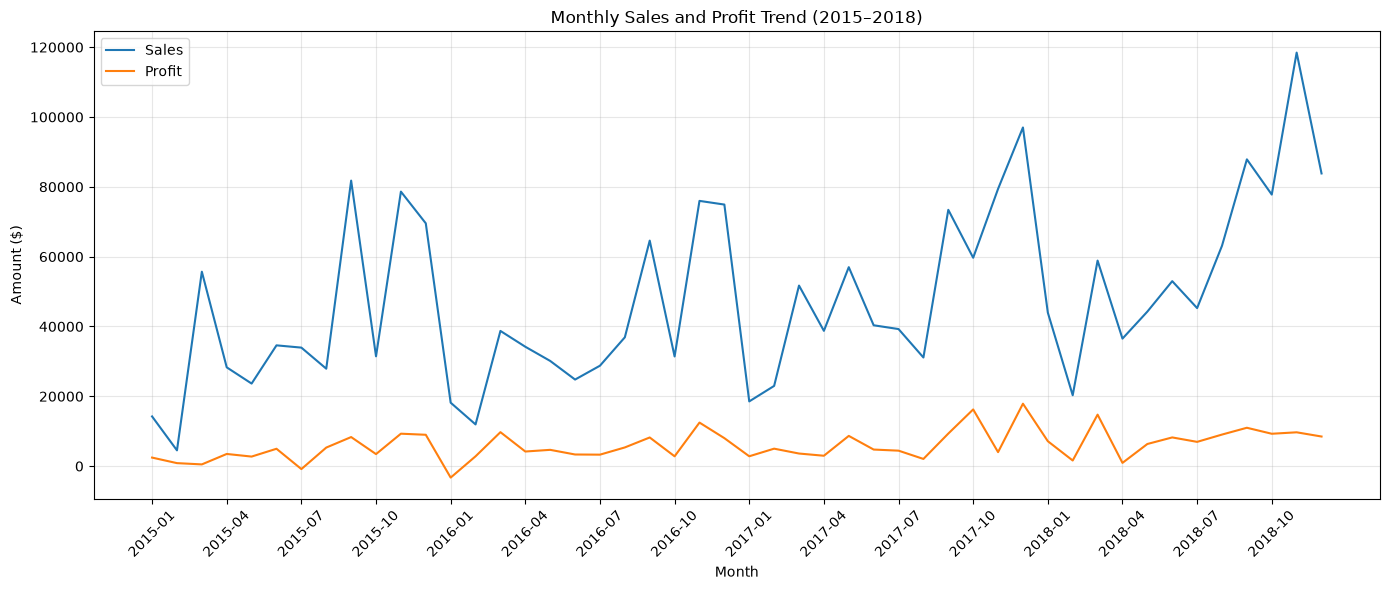

In [40]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_performance["Year-Month"],
    monthly_performance["Sales"],
    label="Sales"
)

plt.plot(
    monthly_performance["Year-Month"],
    monthly_performance["Profit"],
    label="Profit"
)

plt.title("Monthly Sales and Profit Trend (2015–2018)")
plt.xlabel("Month")
plt.ylabel("Amount ($)")
plt.xticks(
    range(0, len(monthly_performance), 3),
    monthly_performance["Year-Month"].iloc[::3],
    rotation=45
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

**Figure 1. Monthly Sales and Profit Trend (2015–2018).**  
Sales and profit fluctuate substantially across the four-year period. The separate panels allow changes in each metric to be viewed at an appropriate scale and highlight that sales volume and profitability do not always move proportionally.

## 8. Visualization 2 — Category Performance

### Purpose

The second visualization compares the three product categories using three complementary measures: sales, total profit, and profit margin.

### Visualization Choice

Three side-by-side bar charts were used because the categories are discrete groups and the objective is to make direct comparisons between them. Separating sales, profit, and profit margin into individual panels also prevents the much larger sales values from visually overwhelming the profit values.

### Insight

Technology generates the highest sales at approximately $836,154 and the highest total profit at approximately $145,455. Its profit margin is 17.40%.

Office Supplies generates approximately $719,047 in sales and $122,491 in profit, resulting in a profit margin of 17.04%.

Furniture generates approximately $741,999 in sales, which is higher than Office Supplies, but its total profit is only approximately $18,451. Its profit margin is 2.49%, substantially lower than the other two categories.

This comparison demonstrates that higher sales do not necessarily translate into higher profitability. Furniture is particularly notable because it produces substantial sales while converting a much smaller proportion of those sales into profit.

### Storytelling Role

This visualization shifts the narrative from overall business performance to product-level performance. It demonstrates why sales alone are insufficient for evaluating business performance and motivates further investigation into profitability patterns.

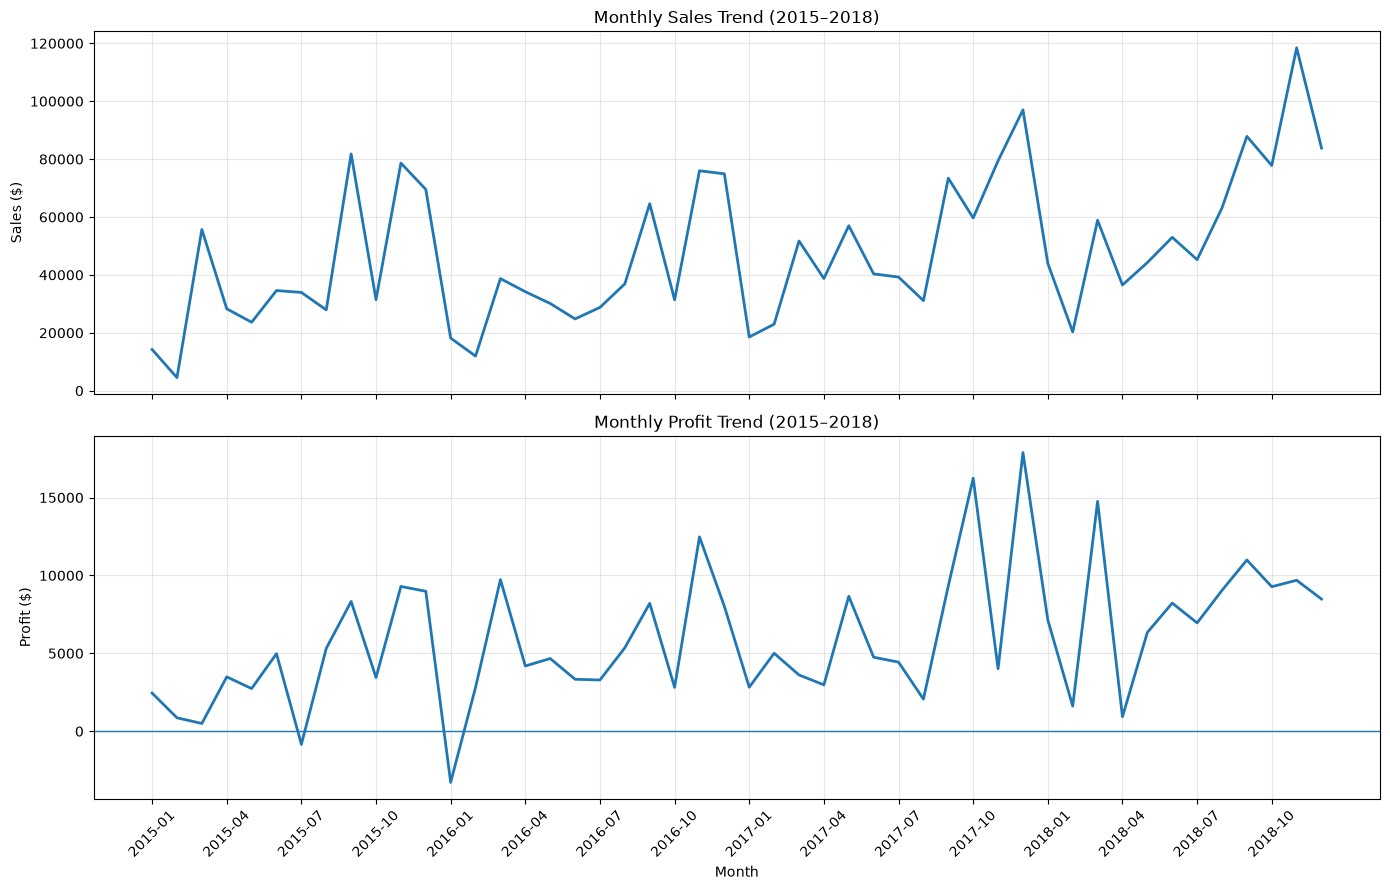

In [41]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 9),
    sharex=True
)

# Sales
axes[0].plot(
    monthly_performance["Year-Month"],
    monthly_performance["Sales"],
    linewidth=2
)

axes[0].set_title("Monthly Sales Trend (2015–2018)")
axes[0].set_ylabel("Sales ($)")
axes[0].grid(alpha=0.3)

# Profit
axes[1].plot(
    monthly_performance["Year-Month"],
    monthly_performance["Profit"],
    linewidth=2
)

axes[1].axhline(
    0,
    linewidth=1
)

axes[1].set_title("Monthly Profit Trend (2015–2018)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Profit ($)")
axes[1].grid(alpha=0.3)

# Show every third month
tick_positions = range(0, len(monthly_performance), 3)

axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(
    monthly_performance["Year-Month"].iloc[::3],
    rotation=45
)

plt.tight_layout()
plt.show()

**Figure 2. Category Performance: Sales, Profit and Profitability.**  
Technology records the highest sales and total profit, while Office Supplies achieves a similar profit margin. Furniture generates substantial sales but has a considerably lower profit margin, highlighting the difference between revenue generation and profitability.

## 9. Visualization 3 — Regional Performance

### Purpose

The third visualization examines whether business performance is consistent across the four regions: West, East, Central, and South.

### Visualization Choice

Two bar charts were used to compare regional sales and profit margin separately. This makes it possible to distinguish between the amount of business generated by a region and the efficiency with which that sales volume is converted into profit.

### Insight

The West region records the highest sales at approximately $725,458 and has a profit margin of 14.94%.

The East region follows with approximately $678,781 in sales and a profit margin of 13.48%.

The Central region generates approximately $501,240 in sales, but its profit margin is only 7.92%. In comparison, the South region generates approximately $391,722 in sales while achieving an 11.93% profit margin.

Therefore, Central generates more sales than South but has a substantially lower profit margin. This demonstrates that regional sales volume alone does not fully represent regional performance.

### Storytelling Role

This visualization extends the category-level finding to geographical performance. It shows that profitability varies across regions and reinforces the importance of considering both sales volume and profit margin when evaluating business performance.

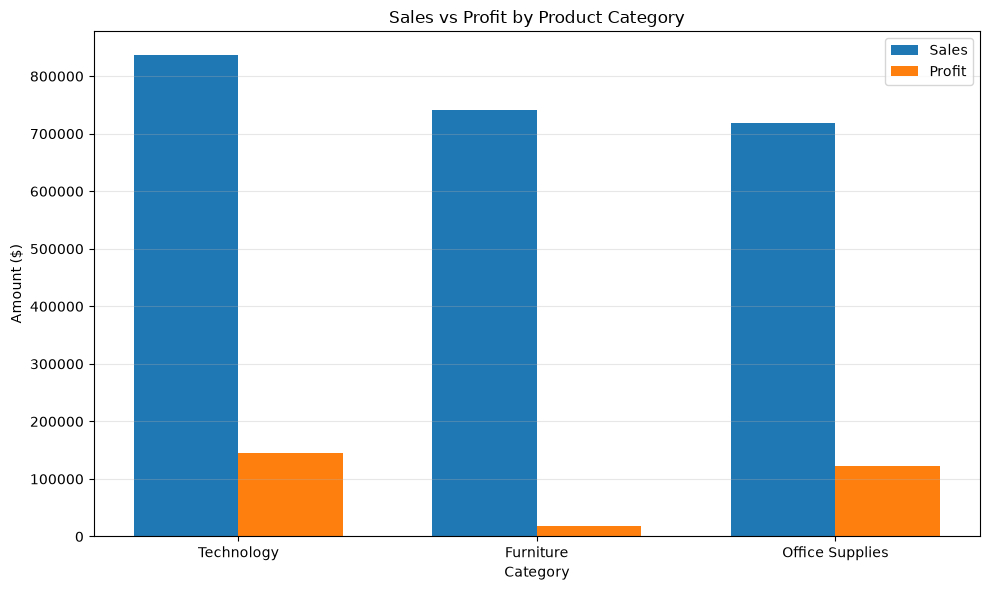

In [42]:
category_plot = category_performance.reset_index()

x = np.arange(len(category_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - width / 2,
    category_plot["Sales"],
    width,
    label="Sales"
)

ax.bar(
    x + width / 2,
    category_plot["Profit"],
    width,
    label="Profit"
)

ax.set_title("Sales vs Profit by Product Category")
ax.set_xlabel("Category")
ax.set_ylabel("Amount ($)")

ax.set_xticks(x)
ax.set_xticklabels(category_plot["Category"])

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Figure 3. Regional Performance: Sales Volume vs Profitability.**  
The West region records the highest sales and profit margin, while the Central region has a notably lower profit margin despite generating more sales than the South region. The comparison demonstrates why both sales volume and profitability should be considered when evaluating regional performance.

## 10. Visualization 4 — Sales vs Profit

### Purpose

The fourth visualization investigates the relationship between sales and profit at the individual transaction level. The objective is to determine whether transactions with higher sales generally tend to produce higher profits.

### Visualization Choice

A scatter plot was selected because each point represents an individual transaction and the chart allows two numerical variables to be examined simultaneously. Product category is represented using different colors to help identify category-level patterns.

A regression line was added to show the overall direction of the relationship without implying causation.

### Insight

The scatter plot shows an overall positive association between sales and profit, meaning that higher-sales transactions are generally associated with higher profits. However, the points show considerable variation around the overall trend.

The visualization also contains transactions below the zero-profit line. These observations represent transactions where sales were recorded but the resulting profit was negative.

The presence of both profitable and loss-making transactions demonstrates that generating sales does not automatically guarantee profitability.

Differences between categories can also be observed, providing additional context for the category-level profitability differences identified earlier.

### Storytelling Role

This visualization moves the analysis from aggregated category and regional comparisons to individual transactions. It provides a more detailed view of the relationship between revenue and profitability and reinforces the central theme that sales and profit should be evaluated together.

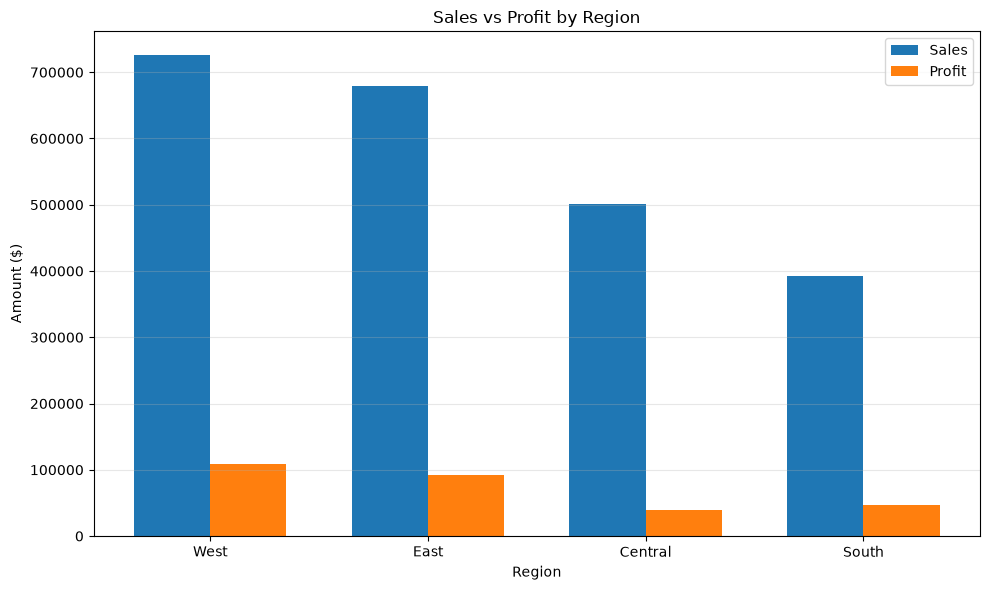

In [43]:
region_plot = region_performance.reset_index()

x = np.arange(len(region_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - width / 2,
    region_plot["Sales"],
    width,
    label="Sales"
)

ax.bar(
    x + width / 2,
    region_plot["Profit"],
    width,
    label="Profit"
)

ax.set_title("Sales vs Profit by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Amount ($)")

ax.set_xticks(x)
ax.set_xticklabels(region_plot["Region"])

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Figure 4. Relationship Between Sales and Profit.**  
The scatter plot indicates an overall positive association between transaction-level sales and profit, while also showing substantial variation and a number of loss-making transactions. The regression line summarizes the overall direction of the relationship but does not imply causation.

## 11. Visualization 5 — Profit Distribution by Category

### Purpose

The fifth visualization examines how transaction-level profit is distributed within each product category. While the previous visualizations focused mainly on aggregated totals and relationships, this analysis looks at the variation between individual transactions.

### Visualization Choice

A box plot was selected because it summarizes the distribution of a numerical variable across multiple categories. It allows the median, central range, overall spread, and unusual observations to be compared between categories.

The final presentation omits extreme outlier points from the display so that the typical distribution is easier to read. The underlying transaction data is not modified or removed.

### Insight

The distribution of transaction-level profit varies considerably across the three categories.

Technology and Office Supplies show relatively wide ranges of transaction-level profit, including both positive and negative observations. Furniture transactions are more concentrated around lower profit values.

The original exploratory box plot also revealed substantial positive and negative outliers. These observations indicate that individual transactions can differ considerably from the typical behavior of their category.

The visualization therefore provides additional context for the category-level results. In particular, the low overall profitability of Furniture is accompanied by transaction-level variation that includes both profitable and loss-making observations.

### Storytelling Role

This visualization adds distributional detail to the earlier category comparison. Instead of considering only total profit or average profitability, it shows how individual transaction outcomes vary within each category.

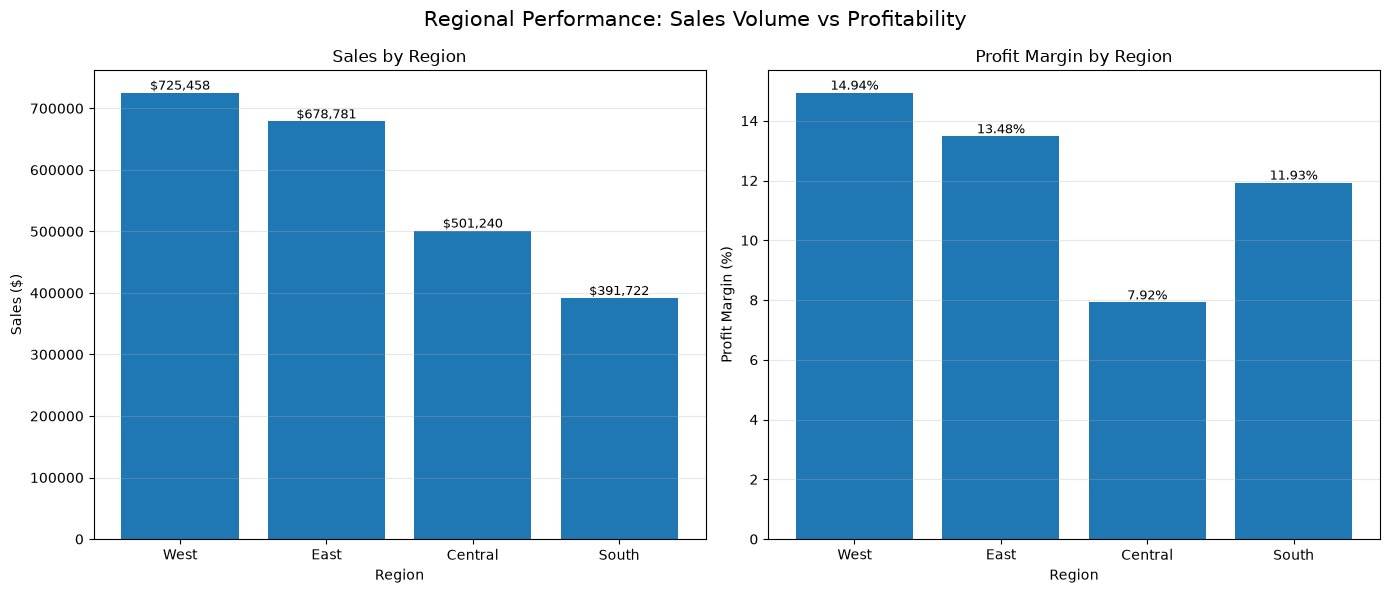

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sales by region
bars1 = axes[0].bar(
    region_plot["Region"],
    region_plot["Sales"]
)

axes[0].set_title("Sales by Region")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Sales ($)")
axes[0].grid(axis="y", alpha=0.3)

for bar in bars1:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Profit margin by region
bars2 = axes[1].bar(
    region_plot["Region"],
    region_plot["Profit Margin %"]
)

axes[1].set_title("Profit Margin by Region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Profit Margin (%)")
axes[1].grid(axis="y", alpha=0.3)

for bar in bars2:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

fig.suptitle(
    "Regional Performance: Sales Volume vs Profitability",
    fontsize=15
)

plt.tight_layout()
plt.show()

**Figure 5. Profit Distribution by Category.**  
Transaction-level profit varies considerably across categories, with Technology and Office Supplies showing wider profit ranges and Furniture concentrated closer to lower profit values. Extreme observations are omitted from the final display for readability but remain part of the underlying dataset.

## 12. Visualization 6 — Category and Region Profitability

### Purpose

The sixth visualization combines the two dimensions examined separately earlier: product category and geographical region. The objective is to identify category-region combinations with notably high or low total profit.

### Visualization Choice

A heatmap was selected because it is effective for displaying values across two categorical dimensions. The color intensity allows differences in total profit to be identified quickly, while the numerical annotations provide the exact values.

### Insight

Technology generates positive profit across all four regions. Its highest regional profit is approximately $47,462 in the East, while its lowest is approximately $19,992 in the South.

Office Supplies also generates positive profit across all regions, with the highest value of approximately $52,610 in the West.

Furniture shows substantially greater variation across regions. Its profit ranges from approximately -$2,871 in the Central region to approximately $11,505 in the West.

The Furniture-Central combination is the only category-region combination in the heatmap with negative total profit.

### Storytelling Role

This visualization provides a more detailed view of the earlier category and regional findings by combining both dimensions. It demonstrates that overall category or regional performance can conceal important differences within specific category-region combinations.

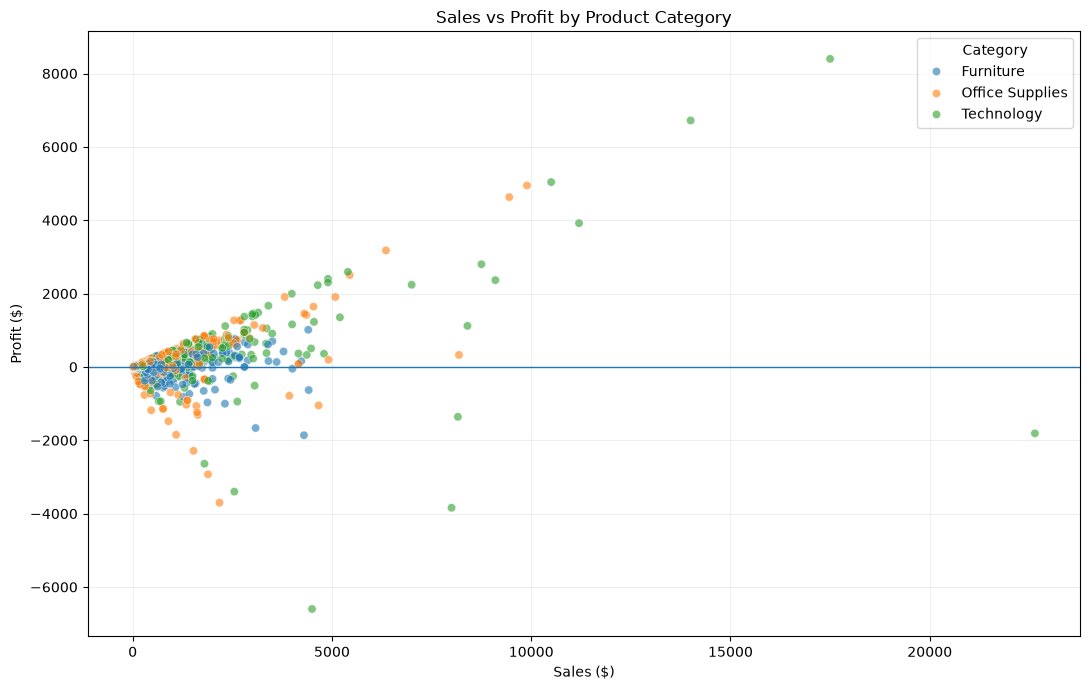

In [45]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_clean,
    x="Sales",
    y="Profit",
    hue="Category",
    alpha=0.6
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Sales vs Profit by Product Category")
plt.xlabel("Sales ($)")
plt.ylabel("Profit ($)")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Figure 6. Profit by Category and Region.**  
The heatmap reveals differences in profitability across category-region combinations. Technology and Office Supplies remain profitable across all regions, while Furniture shows greater variation, including a negative total profit in the Central region.

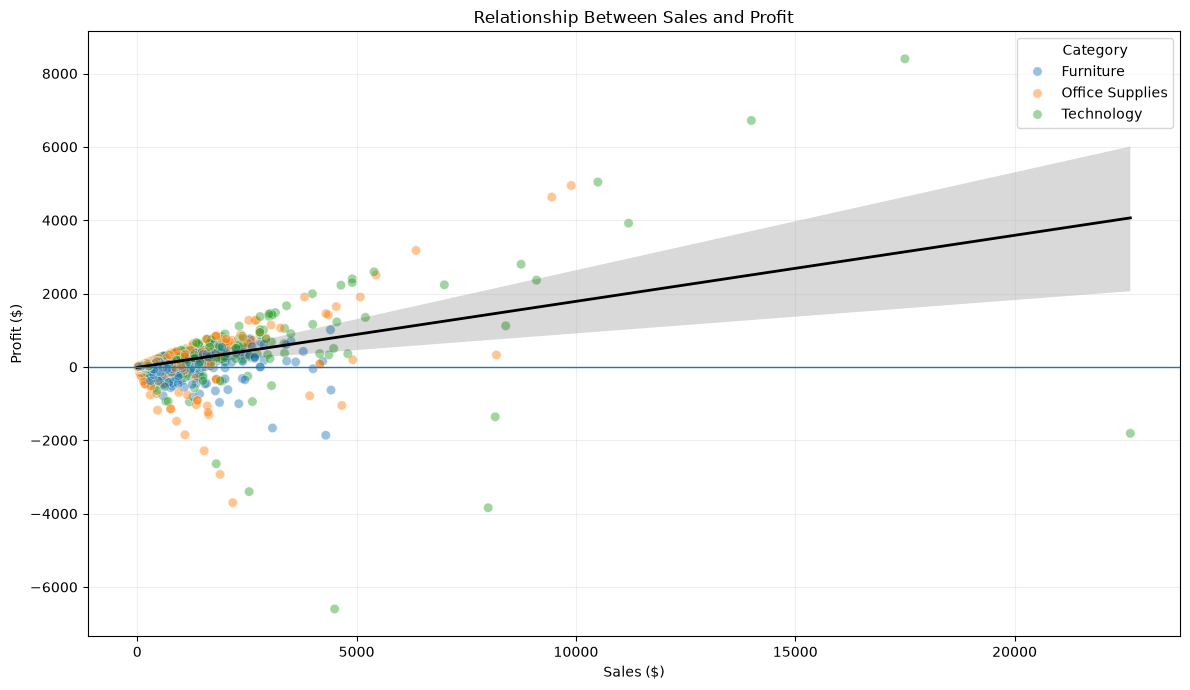

In [46]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_clean,
    x="Sales",
    y="Profit",
    hue="Category",
    alpha=0.45,
    s=45
)

sns.regplot(
    data=df_clean,
    x="Sales",
    y="Profit",
    scatter=False,
    color="black",
    line_kws={"linewidth": 2}
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Relationship Between Sales and Profit")
plt.xlabel("Sales ($)")
plt.ylabel("Profit ($)")

plt.grid(alpha=0.2)
plt.legend(title="Category")

plt.tight_layout()
plt.show()

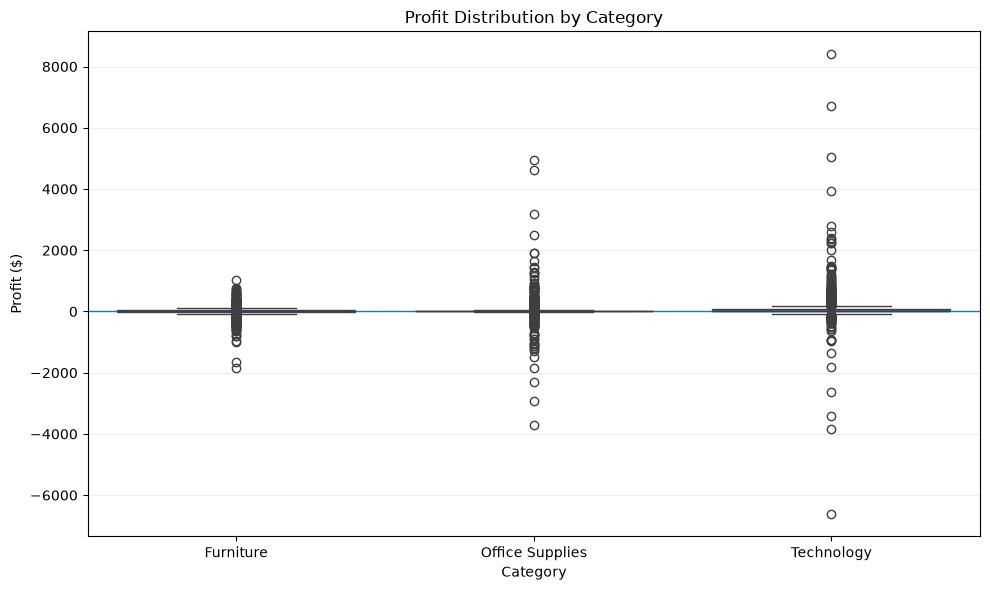

In [47]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="Category",
    y="Profit"
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Profit Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Profit ($)")

plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [48]:
category_region_profit = pd.pivot_table(
    df_clean,
    values="Profit",
    index="Category",
    columns="Region",
    aggfunc="sum"
)

category_region_profit

Region,Central,East,South,West
Category,,,,
Furniture,-2871.0494,3046.1658,6771.2061,11504.9503
Office Supplies,8879.9799,41014.5791,19986.3928,52609.8490
Technology,33697.4320,47462.0351,19991.8314,44303.6496


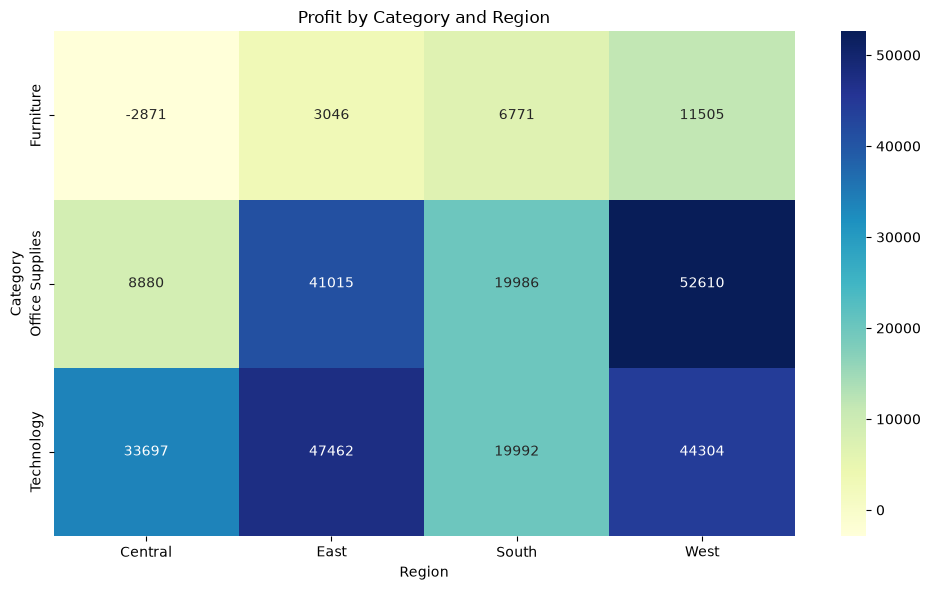

In [49]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    category_region_profit,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Profit by Category and Region")
plt.xlabel("Region")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

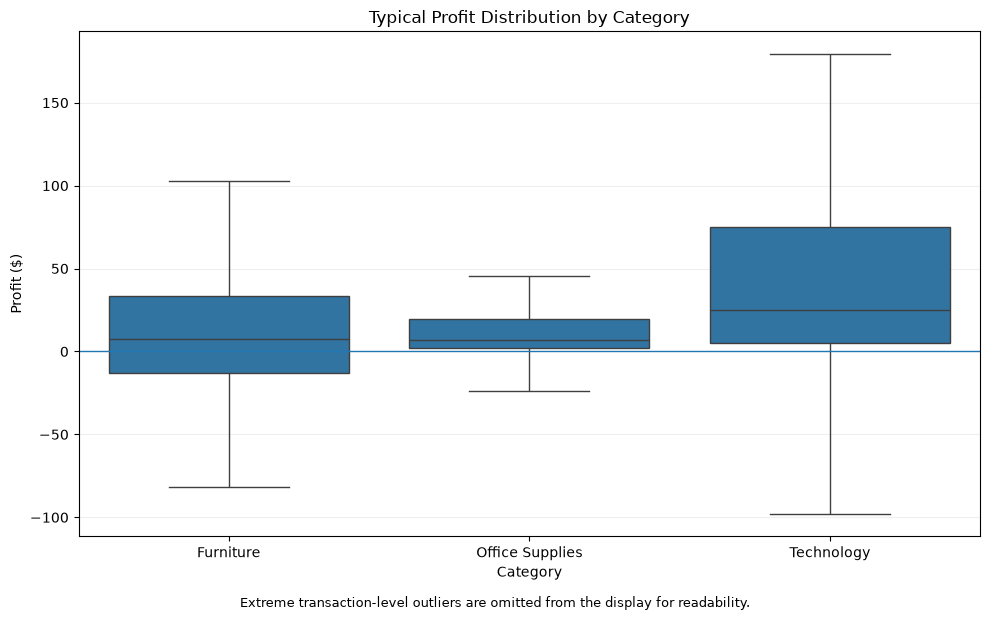

In [50]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="Category",
    y="Profit",
    showfliers=False
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Typical Profit Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Profit ($)")

plt.grid(axis="y", alpha=0.2)

plt.figtext(
    0.5,
    -0.02,
    "Extreme transaction-level outliers are omitted from the display for readability.",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.show()

## 13. Key Insights

The combined analysis produced several important findings:

1. **Business performance varies considerably over time.**  
   Monthly sales and profit fluctuate throughout the 2015–2018 period, with several high-sales periods occurring toward the later part of the dataset.

2. **Technology generates the highest total sales and profit.**  
   Technology records approximately $836,154 in sales and $145,455 in profit, with a profit margin of 17.40%.

3. **Furniture demonstrates a substantial difference between sales and profitability.**  
   Furniture generates approximately $741,999 in sales but only $18,451 in profit, resulting in a 2.49% profit margin.

4. **Regional profitability differs from regional sales volume.**  
   The Central region generates more sales than the South region but has a lower profit margin: 7.92% compared with 11.93%.

5. **Sales and profit have an overall positive association, but the relationship is not uniform.**  
   The transaction-level scatter plot shows considerable variation and includes both profitable and loss-making transactions.

6. **Profitability varies substantially within categories.**  
   The box plot shows considerable variation in transaction-level profit and the presence of extreme positive and negative observations.

7. **Category-region combinations reveal additional patterns.**  
   The heatmap shows that Furniture in the Central region has negative total profit of approximately $2,871, making it the only negative category-region combination in the analysis.

## 14. Business Implications

The findings from the visual analysis suggest several areas that could be considered for further business investigation.

### 1. Evaluate profitability alongside sales

The analysis demonstrates that high sales do not necessarily correspond to high profitability. Furniture generates substantial sales but has a much lower profit margin than Technology and Office Supplies. Business performance should therefore be evaluated using both revenue and profitability measures.

### 2. Investigate category-level profitability

The large difference between Furniture's sales and profit suggests that the category could be examined in greater detail. Further analysis could investigate factors such as discount levels, product-level margins, shipping costs, or individual sub-categories.

### 3. Examine regional differences

The Central region has a lower profit margin than the other regions despite generating more sales than the South. This could justify additional investigation into the products, discounts, customers, or transactions contributing to the difference.

### 4. Investigate loss-making transactions

The sales-versus-profit analysis identifies transactions with negative profit. Examining these transactions could help determine whether particular products, discount levels, regions, or other characteristics are associated with losses.

### 5. Focus on category-region combinations

The heatmap demonstrates that overall category and regional summaries can hide more specific patterns. The negative total profit for Furniture in the Central region provides a specific combination that could be investigated further.

These implications are areas for further analysis rather than conclusions about the underlying causes. The current dataset and visualizations identify patterns but do not establish why those patterns occur.

## 15. Conclusion

This project used Python-based data visualization to transform the Superstore transaction dataset into a structured visual narrative.

The analysis examined business performance from multiple perspectives, beginning with monthly sales and profit trends and progressing to category performance, regional differences, transaction-level relationships, profit distributions, and category-region combinations.

The visualizations demonstrate that sales volume alone does not provide a complete picture of business performance. Technology generates the highest total sales and profit, while Furniture produces substantial sales but has a much lower profit margin. Regional analysis also reveals differences in profitability, particularly between the Central and South regions.

The transaction-level analysis further shows that sales and profit have an overall positive association but that individual transactions can produce both positive and negative outcomes. Finally, the category-region heatmap provides a more detailed view and identifies Furniture in the Central region as a negative-profit combination.

Overall, the project demonstrates how carefully selected visualizations can turn raw transaction data into an understandable narrative. The analysis also highlights areas where additional investigation could provide a deeper understanding of the factors influencing profitability.

## 16. Limitations

This analysis has several limitations:

- The analysis is descriptive and identifies patterns rather than establishing causal relationships.
- The dataset contains an appended returns-related section, which was excluded from the main transaction analysis.
- Eleven missing values remained in the Postal Code column because that field was not required for the planned visualizations.
- The analysis focuses primarily on sales and profit and does not investigate the underlying causes of differences in profitability.
- Extreme transaction-level observations were omitted from the final box-plot display for readability, although they remain part of the underlying dataset.
- Further analysis of discounts, sub-categories, individual products, customers, and shipping characteristics could provide additional explanations for the observed patterns.